# Explore the CBIS-DDSM Dataset

Goal: understand the dataset before preprocessing or modelling.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Project working directory
WORK_DIR = Path.cwd().parent
# Project data directory
DATA_DIR = WORK_DIR / "data"

# Main dataset directory
CBIS_DDSM_DIR = DATA_DIR / "cbis-ddsm"

# Metadata directory
METADATA_DIR = CBIS_DDSM_DIR / "metadata"

# DICOM images
DICOM_DIR = CBIS_DDSM_DIR / "cbis_ddsm"

for p in sorted(CBIS_DDSM_DIR.iterdir()):
    print(f"{p.name} ({'directory' if p.is_dir() else 'file'})")

calc_case_description_test_set.csv (file)
calc_case_description_train_set.csv (file)
cbis_ddsm (directory)
mass_case_description_test_set.csv (file)
mass_case_description_train_set.csv (file)
metadata (directory)


## Inspect CSV

In [2]:
csv_files = list(CBIS_DDSM_DIR.glob("*.csv"))
csv_files.sort()

for csv_file in csv_files:
    print(csv_file.name)

calc_case_description_test_set.csv
calc_case_description_train_set.csv
mass_case_description_test_set.csv
mass_case_description_train_set.csv


In [3]:
dfs = {}
for csv_file in csv_files:
    df_name = csv_file.stem
    dfs[df_name] = pd.read_csv(csv_file)
    print(f"{df_name}: {dfs[df_name].shape}")

calc_case_description_test_set: (326, 14)
calc_case_description_train_set: (1546, 14)
mass_case_description_test_set: (378, 14)
mass_case_description_train_set: (1318, 14)


## Inspect columns and dtypes

In [4]:
mass_train_key = "mass_case_description_train_set"

df = dfs[mass_train_key]
print("Columns:")
print(df.columns.tolist())
print()
print(df.dtypes)
print()
print(df.head(3))

Columns:
['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']

patient_id                   str
breast_density             int64
left or right breast         str
image view                   str
abnormality id             int64
abnormality type             str
mass shape                   str
mass margins                 str
assessment                 int64
pathology                    str
subtlety                   int64
image file path              str
cropped image file path      str
ROI mask file path           str
dtype: object

  patient_id  breast_density left or right breast image view  abnormality id  \
0    P_00001               3                 LEFT         CC               1   
1    P_00001               3                 LEFT        MLO               1   
2    P_00004               

## Pathology Labels

- **BENIGN** - the most common class in both lesion types
- **MALIGNANT** - the positive class for screening purposes
- **BENIGN_WITHOUT_CALLBACK** - benign findings not flagged for recall. Some researchers merge this with BENIGN for binary classification.


In [5]:
train_set_keys = [
    "mass_case_description_train_set",
    "calc_case_description_train_set"
]

for train_set in train_set_keys:
    df = dfs[train_set]
    print(f"{train_set}: {df.shape}")
    print(df["pathology"].value_counts())
    print()

mass_case_description_train_set: (1318, 14)
pathology
MALIGNANT                  637
BENIGN                     577
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64

calc_case_description_train_set: (1546, 14)
pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474
Name: count, dtype: int64



## Class Imbalance

Number of benign cases: 1683
Number of malignant cases: 1181
Ratio (benign/malignant): 1.43


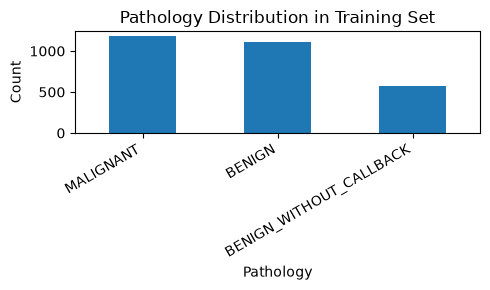

In [6]:
train_set = pd.concat([dfs[k] for k in train_set_keys], ignore_index=True)
n_benign = train_set["pathology"].isin(["BENIGN", "BENIGN_WITHOUT_CALLBACK"]).sum()
n_malignant = train_set["pathology"].isin(["MALIGNANT"]).sum()
print(f"Number of benign cases: {n_benign}")
print(f"Number of malignant cases: {n_malignant}")
print(f"Ratio (benign/malignant): {n_benign / n_malignant:.2f}")

fig, ax = plt.subplots(figsize=(5, 3))
train_set["pathology"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Pathology Distribution in Training Set")
ax.set_xlabel("Pathology")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Image File Paths

- **image file path** - the full mammogram
- **cropped image file path** - a cropped ROI patch
- **ROI mask file path** - a binary lesion mask

In [7]:
image_path_cols = ["image file path", "cropped image file path", "ROI mask file path"]

for col in image_path_cols:
    if col in train_set.columns:
        print(f"### Column: {col} ###")
        print(f"{train_set[col].isnull().sum()} missing values.\n")
        for val in df[col].dropna().sample(3, random_state=42):
            print(f"{val}")
        print()


### Column: image file path ###
0 missing values.

Calc-Training_P_02368_RIGHT_MLO/1.3.6.1.4.1.9590.100.1.2.83894931512491520716958071610436374638/1.3.6.1.4.1.9590.100.1.2.292428926111467282427764660722866053377/1-1.dcm
Calc-Training_P_00673_RIGHT_MLO/1.3.6.1.4.1.9590.100.1.2.197833822011301855324551625571376995112/1.3.6.1.4.1.9590.100.1.2.220985198412071251205855770930886335008/1-1.dcm
Calc-Training_P_01628_RIGHT_MLO/1.3.6.1.4.1.9590.100.1.2.364534151213826115442024336761354960854/1.3.6.1.4.1.9590.100.1.2.360157171311166640209868517473621555491/1-1.dcm

### Column: cropped image file path ###
0 missing values.

Calc-Training_P_02368_RIGHT_MLO_1/1.3.6.1.4.1.9590.100.1.2.340505042111525849640644888551484714150/1.3.6.1.4.1.9590.100.1.2.11961255212766146515711635820867784181/1-1.dcm
Calc-Training_P_00673_RIGHT_MLO_2/1.3.6.1.4.1.9590.100.1.2.119368254413601554226446590843514842765/1.3.6.1.4.1.9590.100.1.2.186090136510273264317243480491308728814/1-1.dcm
Calc-Training_P_01628_RIGHT_MLO_1/1.3

## BI-RADS Density Distribution

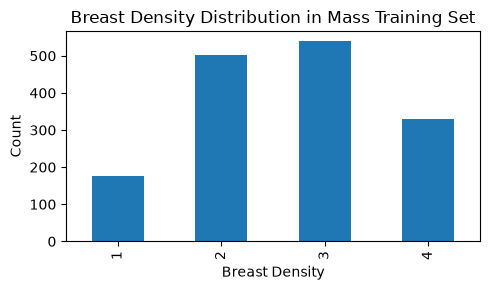

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
df["breast density"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Breast Density Distribution in Mass Training Set")
ax.set_xlabel("Breast Density")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()